<a href="https://colab.research.google.com/github/lvjr3383/AI_Safety/blob/main/ml-basics/PyTorch_Basics_for_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 4: PyTorch Basics for Deep Learning
## Section 1: What is a Tensor?

Welcome.

You already know NumPy arrays from Part 1.  
You already understand shapes and linear algebra from Part 2.  
You already understand gradients from Part 3.

Now we add the last piece that turns those ideas into real neural networks: **PyTorch tensors**.

A tensor is simply a generalization of the arrays you already know:

- Scalar → 0-dimensional tensor (just a single number)
- Vector → 1-dimensional tensor
- Matrix → 2-dimensional tensor
- Higher dimensions → 3D, 4D, … tensors

The big difference from NumPy is that PyTorch tensors can:
1. Automatically track every operation so gradients can be calculated later (autograd)
2. Live on a GPU when you need speed

That’s it. No magic. Just arrays with two extra superpowers that make deep learning possible.

Let’s see them in code.

In [ ]:
import torch
import numpy as np

# A scalar (0D tensor)
scalar = torch.tensor(3.14)
print("Scalar:")
print(scalar)
print("Shape:", scalar.shape)
print("Number of dimensions:", scalar.ndim)

Scalar:
tensor(3.1400)
Shape: torch.Size([])
Number of dimensions: 0


A scalar is just a single number with no dimensions.

Now let’s create a vector (1D tensor).  
This is exactly like a NumPy 1D array.

In [ ]:
# A vector (1D tensor)
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print("Vector:")
print(vector)
print("Shape:", vector.shape)
print("Number of dimensions:", vector.ndim)

Vector:
tensor([1., 2., 3., 4.])
Shape: torch.Size([4])
Number of dimensions: 1


Shape `(4,)` means “4 numbers in a single row”.

Next: a matrix (2D tensor).  
This is the same idea as the matrices you worked with in the Linear Algebra notebook.

In [ ]:
# A matrix (2D tensor)
matrix = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])
print("Matrix:")
print(matrix)
print("Shape:", matrix.shape)
print("Number of dimensions:", matrix.ndim)

Matrix:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Number of dimensions: 2


Shape `(2, 3)` means 2 rows and 3 columns — exactly the shape discipline you learned in Part 2.

Tensors can go higher. A 3D tensor is common when we work with batches of data or images.

In [ ]:
# A 3D tensor (think of it as a stack of matrices)
tensor_3d = torch.tensor([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
print("3D Tensor:")
print(tensor_3d)
print("Shape:", tensor_3d.shape)
print("Number of dimensions:", tensor_3d.ndim)

3D Tensor:
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
Shape: torch.Size([2, 2, 2])
Number of dimensions: 3


### Why not just stay with NumPy?

NumPy is excellent for pure numerical work.  
PyTorch tensors are designed for neural networks.

Two practical differences you will use constantly:

1. They can live on a GPU.
2. They can remember the computation graph so gradients can be calculated automatically.

Let’s prove the first difference right now (even if you only have a CPU available, the code still works).

In [ ]:
# Check whether a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create a tensor and move it to that device
x = torch.tensor([1.0, 2.0, 3.0])
x = x.to(device)
print(x)
print("Device of x:", x.device)

Using device: cpu
tensor([1., 2., 3.])
Device of x: cpu


### Quick comparison with NumPy

You can convert back and forth easily.  
This is useful when you want to use a NumPy function or plot something with Matplotlib.

In [ ]:
# PyTorch → NumPy
pt_tensor = torch.tensor([10.0, 20.0, 30.0])
np_array = pt_tensor.numpy()
print("NumPy array:", np_array)

# NumPy → PyTorch
np_array2 = np.array([40.0, 50.0, 60.0])
pt_tensor2 = torch.from_numpy(np_array2)
print("PyTorch tensor:", pt_tensor2)

NumPy array: [10. 20. 30.]
PyTorch tensor: tensor([40., 50., 60.], dtype=torch.float64)


### What you just learned

- A tensor is a multi-dimensional array (just like NumPy, but with extra powers).
- 0D = scalar, 1D = vector, 2D = matrix, 3D+ = higher-order tensors.
- `.shape` and `.ndim` tell you the structure (shape discipline from Part 2 still applies).
- Tensors can live on CPU or GPU.
- Conversion between NumPy and PyTorch is one line each way.

### Exercise

1. Create a 2×4 tensor filled with the numbers 1 through 8.
2. Print its shape and number of dimensions.
3. Move it to the same device we detected earlier and print the device.

### AI Connection

Every neural network you will ever train is just a series of tensor operations.  
Weights are tensors. Inputs are tensors. Activations are tensors.  
Gradients are also tensors.  

Once you are comfortable creating and inspecting tensors, the rest of deep learning becomes much less mysterious.

Next up we move to **Section 2: Creating and Indexing Tensors**.

## Section 2: Creating and Indexing Tensors

In Section 1 we created tensors by typing the numbers ourselves with `torch.tensor([...])`.

In real work you almost never type every number by hand.  
You need quick ways to create tensors filled with zeros, ones, random numbers, or sequences.

You also need to reach inside a tensor and pull out specific pieces — exactly the same way you did with NumPy arrays.

This section covers both skills.

### Creating tensors the easy way

PyTorch gives you several helper functions.  
We’ll start with the four you will use most often.

In [ ]:
# Create a tensor filled with zeros
zeros = torch.zeros(2, 3)          # 2 rows, 3 columns
print("Zeros:\n", zeros)

# Create a tensor filled with ones
ones = torch.ones(2, 3)
print("\nOnes:\n", ones)

Zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

Ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])


`torch.zeros` and `torch.ones` are perfect when you need a blank slate of a known shape.

Next: random numbers.  
Neural networks start with random weights, so this function is used constantly.

In [ ]:
# Create a tensor filled with random numbers from a normal distribution
random_tensor = torch.randn(2, 3)
print("Random tensor:\n", random_tensor)

Random tensor:
 tensor([[ 0.2856,  0.0606,  0.5480],
        [-0.8872, -1.7450, -0.5269]])


`torch.randn` draws numbers from a standard normal distribution (mean 0, variance 1).  
You will see this again when we initialize model weights.

You can also create a sequence of numbers, just like NumPy’s `arange`.

In [ ]:
# Create a 1D tensor with numbers from 0 to 9
sequence = torch.arange(0, 10)
print("Sequence:", sequence)
print("Shape:", sequence.shape)

Sequence: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Shape: torch.Size([10])


### Indexing and slicing

Indexing works exactly the same way as NumPy.  
You use square brackets `[]` to pick individual elements or ranges.

In [ ]:
import torch

# Create a sample 2D tensor so we have something to index
data = torch.tensor([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])
print("Original tensor:\n", data)
print("Shape:", data.shape)

Original tensor:
 tensor([[ 10,  20,  30,  40],
        [ 50,  60,  70,  80],
        [ 90, 100, 110, 120]])
Shape: torch.Size([3, 4])


Now let’s pull out specific pieces.

In [ ]:
# Single element (row 1, column 2)
print("Element at [1, 2]:", data[1, 2])

# Entire first row
print("First row:", data[0])

# Entire second column
print("Second column:", data[:, 1])

# A slice: rows 0-1, columns 1-3
print("Slice [0:2, 1:3]:\n", data[0:2, 1:3])

Element at [1, 2]: tensor(70)
First row: tensor([10, 20, 30, 40])
Second column: tensor([ 20,  60, 100])
Slice [0:2, 1:3]:
 tensor([[20, 30],
        [60, 70]])


### Changing shape (reshape)

Sometimes the data is correct but the shape is wrong for the next operation.  
`.reshape()` (or `.view()`) lets you rearrange the same numbers into a new shape without changing the values.

In [ ]:
# Start with a 1D tensor of 12 numbers
flat = torch.arange(12)
print("Flat tensor:", flat)
print("Shape:", flat.shape)

# Reshape into 3 rows × 4 columns
reshaped = flat.reshape(3, 4)
print("\nReshaped to (3, 4):\n", reshaped)
print("New shape:", reshaped.shape)

Flat tensor: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape: torch.Size([12])

Reshaped to (3, 4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
New shape: torch.Size([3, 4])


Important rule (shape discipline from Part 2):  
The total number of elements must stay the same.  
`12` elements can become `(3, 4)`, `(2, 6)`, `(4, 3)`, etc., but never `(3, 5)`.

### Moving tensors to GPU (or keeping them on CPU)

In Section 1 we already detected the device.  
Here is the clean pattern you will use in every real training script.

In [ ]:
# Re-detect the device (safe to run again)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create a tensor and immediately send it to the device
x = torch.randn(2, 3).to(device)
print(x)
print("Device of x:", x.device)

Using device: cpu
tensor([[ 0.8974,  1.2259, -1.4919],
        [ 1.1935,  1.2613, -1.7174]])
Device of x: cpu


### What you just learned

- `torch.zeros`, `torch.ones`, `torch.randn`, `torch.arange` create tensors quickly.
- Indexing and slicing work exactly like NumPy.
- `.reshape()` changes the shape while keeping the same data.
- `.to(device)` moves a tensor to GPU (or keeps it on CPU).

### Exercise

1. Create a 4×5 tensor of random numbers.
2. Print the element at row 2, column 3.
3. Reshape the same tensor into shape `(2, 10)` and print the new shape.
4. Move the reshaped tensor to the detected device and confirm its device.

### AI Connection

Almost every line of a real training script starts with creating tensors of the right shape and putting them on the right device.  
Mastering these four creation helpers + indexing + reshape means you can stop fighting the data format and start focusing on the model itself.

Next up we move to **Section 3: Tensor Operations**.

## Section 3: Tensor Operations

You now know how to create tensors and pull pieces out of them.

The next skill is doing math with them.

Almost everything a neural network does is just a sequence of simple tensor operations:  
add, multiply, matrix multiply, and a few shape tricks.

The good news: if you already know NumPy, most of this will feel familiar.

### Element-wise operations

When two tensors have the **same shape**, you can add, subtract, multiply, or divide them element by element.

In [ ]:
a = torch.tensor([[1., 2.],
                  [3., 4.]])

b = torch.tensor([[10., 20.],
                  [30., 40.]])

print("a + b:\n", a + b)
print("\na * b:\n", a * b)   # element-wise multiplication

a + b:
 tensor([[11., 22.],
        [33., 44.]])

a * b:
 tensor([[ 10.,  40.],
        [ 90., 160.]])


Notice that `a * b` multiplies matching positions.  
This is **not** matrix multiplication.  
For matrix multiplication we use a different operator.

### Matrix multiplication (the most important operation)

In deep learning we constantly multiply matrices.  
PyTorch gives you two common ways to do it:

- `torch.matmul(A, B)`
- or the `@` operator (cleaner)

In [ ]:
# 2×3 matrix
A = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])

# 3×2 matrix
B = torch.tensor([[7., 8.],
                  [9., 10.],
                  [11., 12.]])

# Matrix multiplication
C = A @ B
print("A @ B result:\n", C)
print("Shape of result:", C.shape)

A @ B result:
 tensor([[ 58.,  64.],
        [139., 154.]])
Shape of result: torch.Size([2, 2])


Shape check (the linear algebra rule you learned in Part 2):

- A is (2, 3)
- B is (3, 2)
- Result must be (2, 2)

If the inner dimensions do not match, PyTorch will raise an error.  
That error is your friend — it means you broke shape discipline.

### Broadcasting

Just like NumPy, PyTorch can automatically “stretch” a smaller tensor so it matches a larger one.  
This is called **broadcasting**.

In [ ]:
# A 2×3 matrix
matrix = torch.tensor([[1., 2., 3.],
                       [4., 5., 6.]])

# A single number (scalar)
scalar = torch.tensor(10.)

# Broadcasting: the scalar is stretched to match every element
print(matrix + scalar)

tensor([[11., 12., 13.],
        [14., 15., 16.]])


Broadcasting also works with vectors.

In [ ]:
# Same matrix
matrix = torch.tensor([[1., 2., 3.],
                       [4., 5., 6.]])

# A vector of length 3
vector = torch.tensor([10., 20., 30.])

# The vector is added to every row
print(matrix + vector)

tensor([[11., 22., 33.],
        [14., 25., 36.]])


### Useful mathematical functions

PyTorch has many built-in functions that work on entire tensors at once.

In [ ]:
x = torch.tensor([[1., 2.],
                  [3., 4.]])

print("Square root:\n", torch.sqrt(x))
print("\nExponential:\n", torch.exp(x))
print("\nMean of all elements:", torch.mean(x))
print("Sum of all elements:", torch.sum(x))

Square root:
 tensor([[1.0000, 1.4142],
        [1.7321, 2.0000]])

Exponential:
 tensor([[ 2.7183,  7.3891],
        [20.0855, 54.5981]])

Mean of all elements: tensor(2.5000)
Sum of all elements: tensor(10.)


### Moving between NumPy and PyTorch

You will often want to use a NumPy function or plot something with Matplotlib.  
Conversion is one line either way.

In [ ]:
import numpy as np

# PyTorch → NumPy
pt = torch.tensor([1.5, 2.5, 3.5])
np_array = pt.numpy()
print("NumPy version:", np_array)

# NumPy → PyTorch
np_array2 = np.array([4.5, 5.5, 6.5])
pt2 = torch.from_numpy(np_array2)
print("PyTorch version:", pt2)

NumPy version: [1.5 2.5 3.5]
PyTorch version: tensor([4.5000, 5.5000, 6.5000], dtype=torch.float64)


**Important note:**  
When you convert with `.numpy()` or `torch.from_numpy()`, the two objects share the same underlying memory (as long as the tensor is on CPU).  
Changing one will change the other.

### What you just learned

- Element-wise `+`, `-`, `*`, `/` work when shapes match.
- Matrix multiplication uses `@` or `torch.matmul`.
- Broadcasting lets you combine tensors of different shapes.
- Common math functions (`sqrt`, `exp`, `mean`, `sum`) work on whole tensors.
- Easy conversion between NumPy and PyTorch.

### Exercise

1. Create two tensors:  
   - A of shape (3, 4) filled with random numbers  
   - B of shape (4, 2) filled with ones  
2. Multiply them with `@` and print the result shape.  
3. Add the scalar `5` to tensor A using broadcasting and print the result.  
4. Convert the result of step 2 into a NumPy array.

### AI Connection

Every layer in a neural network is basically:
output = input @ weights + bias

That single line is matrix multiplication + broadcasting.  
Once you are comfortable with these operations, you already understand the core calculation that happens inside almost every modern AI model.

Next up we move to **Section 4: requires_grad and Gradients**.

## Section 4: requires_grad and Gradients

So far we have created tensors and done math with them.

Now we add the feature that makes training possible: the ability to automatically calculate gradients.

In Part 3 you learned what a gradient is and how to compute it by hand.  
PyTorch can do that work for you.

### Turning on gradient tracking

By default, tensors do not track operations.  
To enable tracking, set `requires_grad=True` when you create the tensor.

In [ ]:
# Create a tensor that tracks operations
x = torch.tensor(3.0, requires_grad=True)
print(x)
print("requires_grad:", x.requires_grad)

tensor(3., requires_grad=True)
requires_grad: True


Now any calculation that uses this tensor will be recorded.

In [ ]:
# A simple function: y = x²
y = x ** 2
print(y)

tensor(9., grad_fn=<PowBackward0>)


### Calculating the gradient

Call `.backward()` on the result.  
PyTorch then fills in the gradient for every tensor that has `requires_grad=True`.

In [ ]:
y.backward()
print("Gradient of y with respect to x:", x.grad)

Gradient of y with respect to x: tensor(6.)


The mathematical derivative of \( x^2 \) is \( 2x \).  
When \( x = 3 \), the gradient should be \( 6 \).  
That matches what we just got.

### A slightly richer example

Let’s try a function with more than one operation.

In [ ]:
# Reset
x = torch.tensor(2.0, requires_grad=True)

# y = 3x² + 2x + 1
y = 3 * x**2 + 2 * x + 1
print("y =", y)

y.backward()
print("Gradient:", x.grad)

y = tensor(17., grad_fn=<AddBackward0>)
Gradient: tensor(14.)


Derivative of \( 3x^2 + 2x + 1 \) is \( 6x + 2 \).  
When \( x = 2 \), gradient = \( 14 \).  
Again, the numbers match.

### Important rule

You can only call `.backward()` once on a given computation graph (unless you tell PyTorch otherwise).  
After `.backward()`, the gradient is stored in the `.grad` attribute.

### What you just learned

- `requires_grad=True` tells PyTorch to track operations on that tensor.
- Calling `.backward()` computes the gradients.
- The gradient ends up in the `.grad` attribute of the original tensor.
- The values match the derivatives you already know from calculus.

### Exercise

1. Create a tensor `x` with value `4.0` and `requires_grad=True`.
2. Compute `y = x³ + 5x`.
3. Call `.backward()` and print the gradient.
4. Check by hand: the derivative should be \( 3x^2 + 5 \). Does it match?

Next up: Section 5

## Section 5: Gradient Accumulation and Zeroing

In the last section you saw that calling `.backward()` stores the gradient in `.grad`.

There is one important detail: **gradients accumulate by default**.

If you call `.backward()` more than once without clearing the old gradient, the new gradient is added on top of the previous one.

### Seeing accumulation in action

In [ ]:
x = torch.tensor(2.0, requires_grad=True)

# First calculation
y = x ** 2
y.backward()
print("Gradient after first backward:", x.grad)

Gradient after first backward: tensor(4.)


Now run another calculation without clearing the gradient.

In [ ]:
# Second calculation (gradient is not cleared)
y = x ** 2
y.backward()
print("Gradient after second backward:", x.grad)

Gradient after second backward: tensor(8.)


The gradient became 8 instead of 4.  
PyTorch added the new gradient (4) to the old one (4).

This is usually **not** what you want during training.

### How to clear the gradient

Use `.zero_()` (or `.zero_grad()` on an optimizer later) to reset the gradient to zero before the next calculation.

In [ ]:
# Clear the gradient
x.grad.zero_()
print("Gradient after zeroing:", x.grad)

# Now calculate again
y = x ** 2
y.backward()
print("Gradient after new backward:", x.grad)

Gradient after zeroing: tensor(0.)
Gradient after new backward: tensor(4.)


The gradient is correctly 4 again.

### Stopping gradient tracking

Sometimes you only want to run a calculation without tracking gradients at all  
(for example, when you are just evaluating a model).

Two common ways:

In [ ]:
x = torch.tensor(3.0, requires_grad=True)

# Method 1: torch.no_grad()
with torch.no_grad():
    y = x ** 2
    print("y under no_grad:", y)
    print("requires_grad of y:", y.requires_grad)

y under no_grad: tensor(9.)
requires_grad of y: False


Inside the `torch.no_grad()` block, tracking is turned off.

In [ ]:
# Method 2: .detach()
x = torch.tensor(3.0, requires_grad=True)
z = x.detach()
print("z:", z)
print("requires_grad of z:", z.requires_grad)

z: tensor(3.)
requires_grad of z: False


`.detach()` creates a new tensor that shares the data but does not track gradients.

### What you just learned

- Gradients accumulate by default.
- Always clear them with `.zero_()` (or later with `optimizer.zero_grad()`) before a new backward pass.
- Use `torch.no_grad()` or `.detach()` when you do not want gradients tracked.

### Exercise

1. Create a tensor `x = 5.0` with `requires_grad=True`.
2. Compute `y = x ** 2`, call `.backward()`, and print the gradient.
3. Zero the gradient.
4. Compute `y = x ** 3`, call `.backward()`, and print the new gradient.
5. Confirm the second gradient is `3 * 5² = 75`.

Next up: Section 6

## Section 6: Linear Layer from Scratch

A linear layer is the basic building block of most neural networks.

It does one simple thing:

\[
y = Wx + b
\]

- \( x \) is the input
- \( W \) is the weight matrix
- \( b \) is the bias
- \( y \) is the output

In this section we will build that operation ourselves using only the tensor tools you already know.

### Shape discipline reminder (from Part 2)

Before writing any code, remember the shape rules:

- If input \( x \) has shape `(batch_size, in_features)`
- Then weight \( W \) must have shape `(in_features, out_features)`
- Bias \( b \) must have shape `(out_features,)`
- Output \( y \) will have shape `(batch_size, out_features)`

Getting these shapes right is the most common source of errors.  
We will check shapes at every step.

### Step 1: Create a small input

In [ ]:
import torch

# Two examples, each with 3 features
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
print("Input x:\n", x)
print("Shape of x:", x.shape)

Input x:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape of x: torch.Size([2, 3])


Shape `(2, 3)` means: 2 examples, 3 features each.

### Step 2: Create weight and bias

We will map 3 input features to 2 output features.

In [ ]:
# Weight matrix: (in_features=3, out_features=2)
W = torch.tensor([[0.1, 0.2],
                  [0.3, 0.4],
                  [0.5, 0.6]], requires_grad=True)

# Bias: (out_features=2,)
b = torch.tensor([0.1, 0.2], requires_grad=True)

print("Weight W:\n", W)
print("Shape of W:", W.shape)
print("\nBias b:", b)
print("Shape of b:", b.shape)

Weight W:
 tensor([[0.1000, 0.2000],
        [0.3000, 0.4000],
        [0.5000, 0.6000]], requires_grad=True)
Shape of W: torch.Size([3, 2])

Bias b: tensor([0.1000, 0.2000], requires_grad=True)
Shape of b: torch.Size([2])


### Step 3: Compute the linear transformation

This is the actual forward pass:

\[
y = x @ W + b
\]

In [ ]:
y = x @ W + b
print("Output y:\n", y)
print("Shape of y:", y.shape)

Output y:
 tensor([[2.3000, 3.0000],
        [5.0000, 6.6000]], grad_fn=<AddBackward0>)
Shape of y: torch.Size([2, 2])


The output shape is `(2, 2)` — exactly what the shape rules predicted.

### Step 4: Verify with a quick gradient check

Because `W` and `b` have `requires_grad=True`, we can compute gradients.

In [ ]:
# Simple loss: sum of all outputs
loss = y.sum()
loss.backward()

print("Gradient of W:\n", W.grad)
print("\nGradient of b:", b.grad)

Gradient of W:
 tensor([[5., 5.],
        [7., 7.],
        [9., 9.]])

Gradient of b: tensor([2., 2.])


### What you just learned

- A linear layer is just \( y = xW + b \).
- You must match shapes carefully:
  - `x`: `(batch, in_features)`
  - `W`: `(in_features, out_features)`
  - `b`: `(out_features,)`
- The forward pass is matrix multiplication plus broadcasting of the bias.
- Gradients flow automatically when `requires_grad=True`.

### Exercise

1. Create an input tensor of shape `(4, 5)` filled with random numbers.
2. Create a weight matrix that maps 5 features to 3 outputs.
3. Create a matching bias.
4. Compute `y = x @ W + b` and print the shape of `y`.
5. Confirm that the output shape is `(4, 3)`.

Next up: Section 7

## Section 7: Introduction to nn.Linear

In the previous section you built a linear layer by hand:

\[
y = x @ W + b
\]

That was useful for understanding what happens.  
In practice you almost never write it manually.

PyTorch gives you a ready-made version called `nn.Linear`.

### Creating an nn.Linear layer

You only need to tell it two numbers:

- how many input features
- how many output features

In [ ]:
import torch.nn as nn

# Same mapping as before: 3 input features → 2 output features
linear = nn.Linear(in_features=3, out_features=2)
print(linear)

Linear(in_features=3, out_features=2, bias=True)


### Looking at the parameters

The weight and bias are created automatically.  
You can inspect them the same way you did before.

In [ ]:
print("Weight:\n", linear.weight)
print("\nWeight shape:", linear.weight.shape)

print("\nBias:", linear.bias)
print("Bias shape:", linear.bias.shape)

Weight:
 Parameter containing:
tensor([[-0.2465, -0.5637,  0.3671],
        [-0.3901,  0.0859, -0.3888]], requires_grad=True)

Weight shape: torch.Size([2, 3])

Bias: Parameter containing:
tensor([0.1956, 0.0851], requires_grad=True)
Bias shape: torch.Size([2])


Notice the shapes:

- Weight is `(out_features, in_features)` → `(2, 3)`
- Bias is `(out_features,)` → `(2,)`

This is the same information you managed manually, just organized for you.

### Running the forward pass

You no longer write `x @ W + b`.  
You simply call the layer like a function.

In [ ]:
# Same input we used in Section 6
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

y = linear(x)
print("Output:\n", y)
print("Shape:", y.shape)

Output:
 tensor([[-0.0771, -1.2998],
        [-1.4066, -3.3790]], grad_fn=<AddmmBackward0>)
Shape: torch.Size([2, 2])


The result has shape `(2, 2)`, exactly as before.
### Accessing all parameters at once

Later, when we use optimizers, we need a convenient way to get every learnable parameter.  
`.parameters()` does that.

In [ ]:
for param in linear.parameters():
    print(param.shape)

torch.Size([2, 3])
torch.Size([2])


You will see two tensors: the weight and the bias.

### What you just learned

- `nn.Linear(in_features, out_features)` creates a linear layer for you.
- It automatically creates and manages the weight and bias.
- You call it like a function: `output = linear(input)`.
- `.parameters()` gives you all the learnable tensors (needed later for optimizers).
- The underlying math is still \( y = xW^T + b \) (PyTorch stores the weight transposed for efficiency).

### Exercise

1. Create an `nn.Linear` layer that maps 5 features to 3 outputs.
2. Create a random input of shape `(4, 5)`.
3. Pass the input through the layer and print the output shape.
4. Print the shapes of the weight and bias.

Next up: Section 8

## Section 8: Stacking Layers

A single linear layer is rarely enough.  
Most models are built by stacking several layers one after another.

In this section you will learn two clean ways to do that.

### Method 1: Manual stacking

You simply pass the output of one layer into the next.

In [ ]:
# First layer: 4 features → 6 features
layer1 = nn.Linear(4, 6)

# Second layer: 6 features → 2 features
layer2 = nn.Linear(6, 2)

# Sample input: 3 examples, each with 4 features
x = torch.randn(3, 4)

# Forward pass through both layers
h = layer1(x)      # shape: (3, 6)
y = layer2(h)      # shape: (3, 2)

print("Final output shape:", y.shape)

Final output shape: torch.Size([3, 2])


This works, but it becomes messy when you have many layers.

### Method 2: nn.Sequential

`nn.Sequential` lets you list the layers in order.  
PyTorch will pass the data through them automatically.

In [ ]:
model = nn.Sequential(
    nn.Linear(4, 6),
    nn.Linear(6, 2)
)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=6, bias=True)
  (1): Linear(in_features=6, out_features=2, bias=True)
)


Now the forward pass is a single line.

In [ ]:
x = torch.randn(3, 4)
y = model(x)
print("Output:\n", y)
print("Shape:", y.shape)

Output:
 tensor([[ 0.5348, -0.3233],
        [ 0.9545, -0.1496],
        [ 0.1600, -0.2087]], grad_fn=<AddmmBackward0>)
Shape: torch.Size([3, 2])


### Adding a non-linearity

Linear layers alone can only learn linear relationships.  
In practice we almost always insert a non-linear function between them.

The most common simple choice is ReLU.

In [ ]:
model = nn.Sequential(
    nn.Linear(4, 6),
    nn.ReLU(),          # non-linearity
    nn.Linear(6, 2)
)

x = torch.randn(3, 4)
y = model(x)
print("Output shape:", y.shape)

Output shape: torch.Size([3, 2])


### Checking the parameters

Even with multiple layers, `.parameters()` still gives you everything.

In [ ]:
for name, param in model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([6, 4])
0.bias torch.Size([6])
2.weight torch.Size([2, 6])
2.bias torch.Size([2])


### What you just learned

- You can stack layers manually by feeding one output into the next.
- `nn.Sequential` is the cleaner way to do the same thing.
- Adding `nn.ReLU()` (or another activation) between linear layers lets the model learn non-linear patterns.
- `.named_parameters()` shows every weight and bias together with its name.

### Exercise

1. Build a model with `nn.Sequential` that goes:  
   8 inputs → 16 hidden → ReLU → 4 outputs.
2. Create a random input of shape `(5, 8)`.
3. Pass it through the model and confirm the output shape is `(5, 4)`.
4. Print all parameter shapes using `.named_parameters()`.

Next up: Section 9

## Section 9: Loss Functions

A model makes predictions.  
A loss function tells us how far those predictions are from the correct answers.

The loss is a single number.  
Our goal during training is to make that number as small as possible.

### Mean Squared Error (for regression)

When the target is a continuous number (house price, temperature, etc.), we usually use Mean Squared Error.

In [ ]:
# Predictions and targets
predictions = torch.tensor([2.5, 0.0, 2.1, 7.8])
targets     = torch.tensor([3.0, -0.5, 2.0, 8.0])

loss_fn = nn.MSELoss()
loss = loss_fn(predictions, targets)

print("MSE Loss:", loss.item())

MSE Loss: 0.13749997317790985


The loss is the average of the squared differences between predictions and targets.

### Cross Entropy (for classification)

When the target is a class label (cat vs dog, digit 0-9, etc.), we use Cross Entropy Loss.

In [ ]:
# Raw scores (logits) from the model – 3 examples, 4 possible classes
logits = torch.tensor([[1.2, 0.5, -0.3, 2.1],
                       [0.1, 2.5, 0.8, -1.0],
                       [2.0, 0.3, 0.1, 0.4]])

# Correct class for each example
targets = torch.tensor([3, 1, 0])

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, targets)

print("Cross Entropy Loss:", loss.item())

Cross Entropy Loss: 0.40775084495544434


Important:  
`nn.CrossEntropyLoss` expects **raw scores** (logits), not probabilities.  
It applies the softmax internally.

### Using a real model output

Here is how loss looks when connected to a model.

In [ ]:
model = nn.Linear(4, 3)          # 4 features → 3 classes
x = torch.randn(5, 4)            # 5 examples
logits = model(x)                # shape: (5, 3)

targets = torch.tensor([0, 2, 1, 0, 2])

loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, targets)

print("Loss:", loss.item())

Loss: 1.0069880485534668


### What you just learned

- Loss measures how wrong the model is.
- `nn.MSELoss` is used for regression (continuous targets).
- `nn.CrossEntropyLoss` is used for classification (class labels).
- For Cross Entropy, feed it raw logits, not softmax probabilities.
- The loss is a single scalar that we will later try to minimize.

### Exercise

1. Create predictions `torch.tensor([1.0, 3.0, 2.5])` and targets `torch.tensor([1.5, 2.8, 2.0])`.
2. Compute the MSE loss.
3. Create random logits of shape `(4, 5)` and integer targets of shape `(4,)` with values between 0 and 4.
4. Compute the Cross Entropy loss.

Next up: Section 10

## Section 10: Optimizers

You now have:

- a model that makes predictions
- a loss function that measures how wrong those predictions are
- gradients that tell you the direction to improve

An **optimizer** takes the gradients and actually updates the model parameters.

### Stochastic Gradient Descent (SGD)

The simplest optimizer.  
It updates each parameter with the rule:

\[
\text{parameter} = \text{parameter} - \text{learning rate} \times \text{gradient}
\]

In [ ]:
# Simple model
model = nn.Linear(3, 1)

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(optimizer)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### The basic training step

Every training step follows the same four lines:

1. Clear old gradients
2. Compute the loss
3. Compute new gradients (`.backward()`)
4. Update the parameters (`.step()`)

In [ ]:
# Dummy data
x = torch.randn(5, 3)
y = torch.randn(5, 1)

loss_fn = nn.MSELoss()

# One training step
optimizer.zero_grad()          # 1. clear gradients
predictions = model(x)         # forward pass
loss = loss_fn(predictions, y) # 2. compute loss
loss.backward()                # 3. compute gradients
optimizer.step()               # 4. update parameters

print("Loss:", loss.item())

Loss: 0.9460489153862


### Adam optimizer

Adam is a more modern optimizer that usually converges faster than plain SGD.  
You use it the same way.

In [ ]:
model = nn.Linear(3, 1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Same four lines
optimizer.zero_grad()
predictions = model(x)
loss = loss_fn(predictions, y)
loss.backward()
optimizer.step()

print("Loss:", loss.item())

Loss: 1.9757639169692993


### Putting it in a small loop

In real training you repeat the four steps many times.

In [ ]:
model = nn.Linear(3, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

x = torch.randn(20, 3)
y = torch.randn(20, 1)

for epoch in range(10):
    optimizer.zero_grad()
    predictions = model(x)
    loss = loss_fn(predictions, y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 2, Loss: 0.7855
Epoch 4, Loss: 0.7408
Epoch 6, Loss: 0.7103
Epoch 8, Loss: 0.6890
Epoch 10, Loss: 0.6738


### What you just learned

- An optimizer updates the model parameters using the gradients.
- The core training step is always the same four lines:
  1. `optimizer.zero_grad()`
  2. Forward pass + loss
  3. `loss.backward()`
  4. `optimizer.step()`
- SGD is the classic choice; Adam is a strong default for most problems.
- You repeat these steps in a loop (called training epochs).

### Exercise

1. Create a linear model that maps 5 features to 1 output.
2. Use the Adam optimizer with learning rate 0.01.
3. Create random input `(10, 5)` and target `(10, 1)`.
4. Run 20 training steps and print the loss every 5 steps.

Next up: Section 11

## Section 11: Building Custom nn.Module

So far we have used `nn.Linear` and `nn.Sequential`.

For anything more flexible, we create our own model class by inheriting from `nn.Module`.

This is the standard way to define models in PyTorch.

### The basic pattern

Every custom model needs two methods:

- `__init__` → define the layers
- `forward` → describe how data flows through those layers

In [4]:
import torch.nn as nn
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 8)
        self.layer2 = nn.Linear(8, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        return x

### Creating and using the model

In [5]:
model = SimpleNet()
print(model)

SimpleNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=2, bias=True)
)


You call it exactly like any other layer.

In [7]:
import torch
x = torch.randn(3, 4)
output = model(x)
print("Output shape:", output.shape)

Output shape: torch.Size([3, 2])


### Why this structure matters

- All parameters registered inside `__init__` are automatically tracked.
- `.parameters()` and `.named_parameters()` work without any extra code.
- You can add any Python logic you want inside `forward`.

In [8]:
for name, param in model.named_parameters():
    print(name, param.shape)

layer1.weight torch.Size([8, 4])
layer1.bias torch.Size([8])
layer2.weight torch.Size([2, 8])
layer2.bias torch.Size([2])


### A slightly cleaner version with ReLU as a layer

In [9]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = SimpleNet()
x = torch.randn(3, 4)
print(model(x).shape)

torch.Size([3, 2])


### What you just learned

- Custom models inherit from `nn.Module`.
- Define layers in `__init__`.
- Describe the computation in `forward`.
- Calling `model(x)` automatically runs `forward`.
- Parameters are tracked automatically so optimizers can update them.

### Exercise

1. Write a custom model class that maps 6 inputs → 12 hidden → ReLU → 3 outputs.
2. Create an instance of the model.
3. Pass a random tensor of shape `(5, 6)` through it.
4. Confirm the output shape is `(5, 3)`.
5. Print all parameter names and shapes.

Next up: Section 12

## Section 12: Training Loop Best Practices

You already know the four core lines of a training step.  
This section adds the small but important habits that make training reliable.

### The complete training step (review)

Here is the clean version you should use every time:

In [10]:
model = SimpleNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

x = torch.randn(8, 4)
targets = torch.randint(0, 2, (8,))

# Standard training step
model.train()                  # set model to training mode
optimizer.zero_grad()
predictions = model(x)
loss = loss_fn(predictions, targets)
loss.backward()
optimizer.step()

print("Loss:", loss.item())

Loss: 0.6851111054420471


### Train mode vs Eval mode

Some layers behave differently during training and during evaluation  
(for example Dropout or BatchNorm).

Always switch modes explicitly.

In [11]:
model.train()   # training mode
print("Training mode:", model.training)

model.eval()    # evaluation mode
print("Eval mode:", model.training)

Training mode: True
Eval mode: False


### No gradients during evaluation

When you are only making predictions (not training), turn off gradient tracking.  
This saves memory and makes the code faster.

In [12]:
model.eval()

with torch.no_grad():
    predictions = model(x)
    print("Predictions shape:", predictions.shape)

Predictions shape: torch.Size([8, 2])


### A clean mini training + evaluation pattern

In [13]:
model = SimpleNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

x = torch.randn(16, 4)
targets = torch.randint(0, 2, (16,))

for epoch in range(5):
    # --- Training ---
    model.train()
    optimizer.zero_grad()
    predictions = model(x)
    loss = loss_fn(predictions, targets)
    loss.backward()
    optimizer.step()

    # --- Evaluation ---
    model.eval()
    with torch.no_grad():
        val_predictions = model(x)
        val_loss = loss_fn(val_predictions, targets)

    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

Epoch 1 | Train Loss: 0.7617 | Val Loss: 0.7463
Epoch 2 | Train Loss: 0.7463 | Val Loss: 0.7324
Epoch 3 | Train Loss: 0.7324 | Val Loss: 0.7196
Epoch 4 | Train Loss: 0.7196 | Val Loss: 0.7076
Epoch 5 | Train Loss: 0.7076 | Val Loss: 0.6966


### What you just learned

- Always call `model.train()` before training steps.
- Always call `model.eval()` before evaluation or inference.
- Wrap evaluation code in `torch.no_grad()` so gradients are not tracked.
- The core training step stays the same four lines, just with clearer mode handling.

### Exercise

1. Create a simple model (any architecture you like).
2. Write a loop of 8 epochs.
3. In each epoch: run one training step, then one evaluation step under `torch.no_grad()`.
4. Print both the training loss and the evaluation loss each epoch.

Next up: Section 13

## Section 13: Dataset and DataLoader Basics

So far we have been feeding the whole dataset to the model at once.  
In real work the data is often too large for that.

PyTorch gives us two tools:

- `Dataset` → knows how to get one example
- `DataLoader` → handles batching, shuffling, and iteration

### Creating a simple Dataset

A Dataset only needs two methods:

- `__len__` → how many examples
- `__getitem__` → return one example by index

In [14]:
from torch.utils.data import Dataset, DataLoader

class TinyDataset(Dataset):
    def __init__(self):
        self.data = torch.randn(20, 4)      # 20 examples, 4 features
        self.targets = torch.randint(0, 2, (20,))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

dataset = TinyDataset()
print("Number of examples:", len(dataset))
print("First example:", dataset[0])

Number of examples: 20
First example: (tensor([ 1.1651, -2.1150,  1.3766,  0.5155]), tensor(1))


### Why we need a DataLoader

The DataLoader takes the Dataset and gives us:

- automatic batching
- shuffling
- easy iteration

In [15]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch_x, batch_y in loader:
    print("Batch X shape:", batch_x.shape)
    print("Batch y shape:", batch_y.shape)
    break   # just look at the first batch

Batch X shape: torch.Size([4, 4])
Batch y shape: torch.Size([4])


Each batch has shape `(batch_size, features)`.

### Walking through all batches

In [16]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for i, (batch_x, batch_y) in enumerate(loader):
    print(f"Batch {i+1}: X {batch_x.shape}, y {batch_y.shape}")

Batch 1: X torch.Size([4, 4]), y torch.Size([4])
Batch 2: X torch.Size([4, 4]), y torch.Size([4])
Batch 3: X torch.Size([4, 4]), y torch.Size([4])
Batch 4: X torch.Size([4, 4]), y torch.Size([4])
Batch 5: X torch.Size([4, 4]), y torch.Size([4])


### Using the DataLoader inside a training loop

In [17]:
model = nn.Linear(4, 2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    total_loss = 0

    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Average Loss: {total_loss / len(loader):.4f}")

Epoch 1, Average Loss: 0.9410
Epoch 2, Average Loss: 0.9274
Epoch 3, Average Loss: 0.9129


### What you just learned

- A `Dataset` knows how to return one example.
- A `DataLoader` turns the Dataset into batches and can shuffle them.
- You iterate over the DataLoader with a simple `for` loop.
- Real training almost always happens one batch at a time.

### Exercise

1. Create a Dataset with 30 examples, each having 5 features and a binary target.
2. Wrap it in a DataLoader with `batch_size=6` and `shuffle=True`.
3. Print the shape of every batch.
4. Run one full epoch of training using the loop pattern above.

Next up: Section 14

## Section 14: Working with Real Data

Until now we have used tiny made-up tensors.  
In this section we load a real dataset, apply simple transforms, and prepare it for training.

### Loading MNIST

MNIST is a classic dataset of handwritten digits (0-9).  
PyTorch makes it easy to download and load.

In [18]:
from torchvision import datasets, transforms

# Define a simple transform: convert images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training set
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Number of training examples:", len(train_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.13MB/s]

Number of training examples: 60000


### Looking at one example

In [19]:
image, label = train_data[0]
print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


Shape `(1, 28, 28)` means: 1 channel (grayscale), 28×28 pixels.

### Creating a DataLoader for MNIST

In [21]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Look at one batch
for images, labels in train_loader:
    print("Batch of images shape:", images.shape)
    print("Batch of labels shape:", labels.shape)
    break

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])


### Loading the test set

We also keep a separate test set so we can measure performance on unseen data.

In [22]:
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print("Number of test examples:", len(test_data))

Number of test examples: 10000


### Quick sanity check

In [23]:
print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 938
Test batches: 157


### What you just learned

- `datasets.MNIST` downloads and prepares the handwritten digit data.
- `transforms.Compose` lets you chain simple preprocessing steps.
- We create separate DataLoaders for training and testing.
- Images come out as tensors of shape `(batch, 1, 28, 28)`.

### Exercise

1. Print the shape and label of the 10th training example.
2. Create a DataLoader for the training set with `batch_size=128`.
3. Iterate through one batch and confirm the shapes are `(128, 1, 28, 28)` for images and `(128,)` for labels.
4. Confirm how many batches are in both the training and test loaders.

Next up: Section 15

## Section 15: Building a Small MLP

Now we put everything together and train a real model on MNIST.

We will:

- define a small multi-layer network
- split the data into train and validation
- train for a few epochs
- print both loss and accuracy

### Defining the model

A simple network that flattens the 28×28 image and passes it through two linear layers.

In [24]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = MNISTNet()
print(model)

MNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


### Preparing a small validation split

We take a portion of the training data to act as validation so we can watch performance during training.

In [27]:
from torch.utils.data import random_split

# Use a smaller subset for faster demonstration
# The full MNIST training dataset has 60,000 examples.
# We want 5000 for training, 1000 for validation.
# The remaining 54,000 examples will be ignored for this demo.
small_train_size = 5000
small_val_size = 1000
remaining_size = len(train_data) - small_train_size - small_val_size

small_train, small_val, _ = random_split(train_data, [small_train_size, small_val_size, remaining_size])

train_loader = DataLoader(small_train, batch_size=64, shuffle=True)
val_loader   = DataLoader(small_val,   batch_size=64, shuffle=False)

### Loss function and optimizer

In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training loop with accuracy

We will track both loss and accuracy on the validation set after each epoch.

In [29]:
def accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_acc = accuracy(val_loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

Epoch 1 | Loss: 1.0381 | Val Accuracy: 85.20%
Epoch 2 | Loss: 0.4515 | Val Accuracy: 88.00%
Epoch 3 | Loss: 0.3711 | Val Accuracy: 89.10%
Epoch 4 | Loss: 0.3381 | Val Accuracy: 87.60%
Epoch 5 | Loss: 0.3091 | Val Accuracy: 88.50%


### What you just learned

- A full training loop contains: model definition, data loaders, loss, optimizer, and the train/eval cycle.
- We keep a validation set to measure accuracy while training.
- Accuracy is calculated by comparing the predicted class with the true label.
- Even a small network can learn useful patterns on MNIST in just a few epochs.

### Exercise

1. Change the hidden size from 128 to 256 and retrain for 3 epochs.
2. Print the validation accuracy after each epoch.
3. Try a different learning rate (for example 0.01) and observe what happens to the loss.

Next up: Section 16

## Section 16: Evaluation and Monitoring

Training a model is only half the work.  
You also need clear ways to measure how well it is doing and to decide when to stop.

### Calculating accuracy (review)

Accuracy is simply the percentage of examples the model gets right.

In [30]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total
    return avg_loss, acc

### Comparing train and validation performance

In [31]:
train_loss, train_acc = evaluate(train_loader)
val_loss, val_acc = evaluate(val_loader)

print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

Train Loss: 0.2961 | Train Acc: 91.32%
Val Loss:   0.3792 | Val Acc:   88.50%


If training accuracy is much higher than validation accuracy, the model may be memorizing the training data (overfitting).

### Watching the gap over epochs

It is useful to store the metrics so you can see the trend.

In [32]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(5):
    # Training
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

    # Evaluation
    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1 | Train Loss: 0.2692 | Val Loss: 0.3506 | Val Acc: 89.60%
Epoch 2 | Train Loss: 0.2508 | Val Loss: 0.3245 | Val Acc: 90.10%
Epoch 3 | Train Loss: 0.2249 | Val Loss: 0.3257 | Val Acc: 90.30%
Epoch 4 | Train Loss: 0.1938 | Val Loss: 0.3037 | Val Acc: 90.80%
Epoch 5 | Train Loss: 0.1971 | Val Loss: 0.3197 | Val Acc: 90.50%


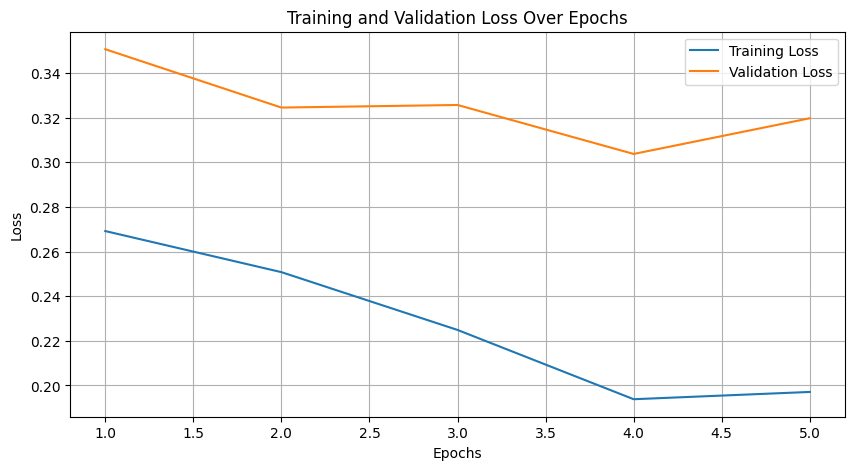

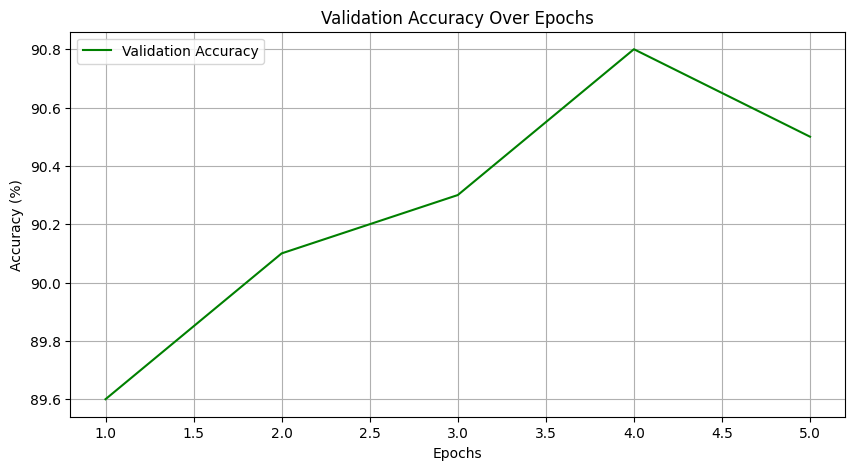

In [40]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

This plot helps to visually confirm the gap between training and validation performance, and also helps in deciding when to stop training based on validation metrics.

This plot helps to visually confirm the gap between training and validation performance, and also helps in deciding when to stop training based on validation metrics.

### Early stopping intuition

If the validation loss stops improving (or starts getting worse) while training loss keeps falling, it is usually a good time to stop.

You do not need complicated code for this yet — simply watch the validation numbers and decide.

### What you just learned

- Always measure both loss and accuracy on a validation set.
- A large gap between train and validation performance is a warning sign.
- Tracking metrics over epochs helps you see whether the model is still improving.
- Early stopping is the simple idea of stopping when validation performance no longer improves.

### Exercise

1. Run 8 more epochs and record the validation accuracy each time.
2. Note the epoch where validation accuracy was highest.
3. Compare the final train accuracy with the final validation accuracy. Is there a gap?

Next up: Section 17

## Section 17: Debugging & Gotchas

Most of the time spent building models is spent fixing errors.  
This section covers the problems you will meet most often and how to recognize them quickly.

### 1. Shape mismatches

This is the most common error.  
Always print shapes when something goes wrong.

In [34]:
x = torch.randn(32, 28, 28)   # missing the channel dimension
model = MNISTNet()

try:
    output = model(x)
except Exception as e:
    print("Error:", e)

The model expects `(batch, 1, 28, 28)`.  
Fix it by adding the missing dimension or reshaping.

In [35]:
x = torch.randn(32, 1, 28, 28)
output = model(x)
print("Success. Output shape:", output.shape)

Success. Output shape: torch.Size([32, 10])


### 2. Forgetting to zero gradients

If you forget `optimizer.zero_grad()`, gradients accumulate and the model updates incorrectly.

In [36]:
# Wrong (gradients accumulate)
# loss.backward()
# optimizer.step()

# Correct
optimizer.zero_grad()
# loss.backward()
# optimizer.step()

### 3. Forgetting model.train() / model.eval()

Some layers behave differently in training and evaluation modes.  
Always switch explicitly.

In [37]:
model.train()   # before training steps
model.eval()    # before evaluation or inference

MNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)

### 4. Gradients not flowing

If you use `.detach()`, `torch.no_grad()`, or convert to NumPy too early, gradients stop.

In [38]:
x = torch.randn(5, 4, requires_grad=True)

# This breaks the gradient
y = x.detach()
z = y * 2
# z.backward()  → would fail

# This keeps the gradient
y = x * 2
z = y.sum()
z.backward()
print("Gradient exists:", x.grad is not None)

Gradient exists: True


### 5. Device mismatches

All tensors and the model must be on the same device (CPU or GPU).

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Later, when loading a batch:
# images = images.to(device)
# labels = labels.to(device)

### 6. Vanishing or exploding gradients (quick intuition)

- **Vanishing**: gradients become extremely small → learning stalls  
- **Exploding**: gradients become extremely large → loss becomes NaN

Common protections: proper weight initialization, gradient clipping, and using ReLU (or similar) activations.

### Quick debugging checklist

When something fails, check in this order:

1. Print the shapes of your tensors
2. Confirm `optimizer.zero_grad()` is called
3. Confirm `model.train()` / `model.eval()` are used correctly
4. Confirm everything is on the same device
5. Check whether any tensor was accidentally detached

### What you just learned

- Shape errors are the most frequent problem — print shapes early.
- Always zero gradients before the backward pass.
- Switch between train and eval modes deliberately.
- Keep all tensors on the same device.
- Gradients can disappear if you detach too early.
- A short checklist solves most training bugs quickly.

### Exercise

1. Intentionally create a shape error and fix it by printing shapes.
2. Write a tiny training loop and deliberately forget `zero_grad()`. Observe what happens to the loss.
3. Move a model and a batch of data to the available device and confirm they match.

---

**You have completed Part 4: PyTorch Basics for ML.**